# TrialOutcome M1 -- The Leakage Demo

**M9 UPDATE (2026-08-03):** re-executed after `enrollment_count`/`log_enrollment_count`/
`enrollment_missing` were dropped as target leakage (`decisions.md` M9-1) -- a DIFFERENT
leakage question than this notebook tests. This notebook is about *row-placement* leakage
(does a random split let future information leak backward?); M9's finding is about *feature
semantics* (is a value knowable at `start_date` at all?). The two are orthogonal: dropping
enrollment changes every number below (it was the dominant feature here too, though far less
dominant for a linear model than it was for the M2 XGBoost champion), but the qualitative
finding -- temporal-split row-placement leakage is a non-issue for this feature set -- is
unaffected by which columns are IN that feature set. Numbers updated by direct re-execution,
not hand-edited.

Train the same `LogisticRegression` pipeline on the exact same engineered features under two different split strategies: a **random** 60/20/20 split and the **temporal** split (train < 2020, calib 2020-2022, test >= 2022). Same features, same model, same hyperparameters -- the only difference is how rows are assigned to train/test.

The naive expectation is that the random split will show inflated performance from leakage. The numbers below don't cooperate with that story on first look -- working out *why* (and running a properly controlled ablation to isolate the real mechanism) is more informative than the naive gap would have been.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from domains.pharma.dataset_builder import PharmaDatasetBuilder
from core.dataset_builder_base import SplitDates

builder = PharmaDatasetBuilder()
raw = builder.fetch_raw()
feat = builder.build_features(raw)
print(len(feat), "rows engineered")

[build_features] 78115 rows after filters. Null rates:
  enrollment_count: 0.0157
  num_primary_outcomes: 0.0350
  num_sites: 0.0843
  allocation: 0.0220
  masking: 0.0232
  has_dmc: 0.2077
  eligibility_criteria: 0.0002
  condition_name: 0.0000
  sponsor_class: 0.0000
  sponsor_prior_termination_rate: 0.0000


78115 rows engineered


## Build the two split versions

One-hot vocabulary for `condition_name` is fit on each split's own train partition (see `PharmaDatasetBuilder._one_hot_condition`), so the two datasets have independently-fit condition dummies -- this mirrors what would actually happen if each pipeline were built end-to-end.

In [2]:
split_cfg = builder.config["split"]
dates = SplitDates(
    train_end=pd.Timestamp(split_cfg["train_end"]),
    calib_end=pd.Timestamp(split_cfg["calib_end"]),
)

temporal = builder.temporal_split(feat, date_col="start_date", split_dates=dates)
temporal, temporal_cond_cols = builder._one_hot_condition(temporal)

random = builder.random_split(feat, random_state=split_cfg["random_state"])
random, random_cond_cols = builder._one_hot_condition(random)

print("Temporal split counts:\n", temporal["split"].value_counts(), "\n")
print("Random split counts:\n", random["split"].value_counts())

Temporal split counts:
 split
train    66105
calib     6310
test      5700
Name: count, dtype: int64 

Random split counts:
 split
train    46869
test     15623
calib    15623
Name: count, dtype: int64


In [3]:
CATEGORICAL = ["phase", "allocation", "masking", "has_dmc_str", "sponsor_class"]
# M9: log_enrollment_count / enrollment_missing removed -- target leakage, dropped from
# build_features() entirely in M9 (decisions.md M9-1). See cell 0's M9 note: this doesn't
# change what this notebook is testing (row-placement, not feature semantics).
NUMERIC = [
    "num_primary_outcomes",
    "num_sites",
    "has_results",
    "eligibility_criteria_length",
    "exclusion_keyword_count",
    "sponsor_prior_trial_count",
    "sponsor_prior_termination_rate",
    "condition_rarity",
    "start_year",
    "start_quarter",
]


def make_pipeline(condition_cols):
    pre = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
            ("num", "passthrough", NUMERIC + condition_cols),
        ]
    )
    return Pipeline(
        [
            ("pre", pre),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
        ]
    )


def fit_eval(df, condition_cols):
    train = df[df["split"] == "train"]
    test = df[df["split"] == "test"]
    cols = CATEGORICAL + NUMERIC + condition_cols
    pipe = make_pipeline(condition_cols)
    pipe.fit(train[cols], train["label"])
    proba = pipe.predict_proba(test[cols])[:, 1]
    pr_auc = average_precision_score(test["label"], proba)
    return pipe, test["label"], proba, pr_auc

In [4]:
temporal_pipe, temporal_y, temporal_proba, temporal_pr_auc = fit_eval(temporal, temporal_cond_cols)
random_pipe, random_y, random_proba, random_pr_auc = fit_eval(random, random_cond_cols)

print(f"Temporal split PR-AUC: {temporal_pr_auc:.4f}")
print(f"Random split PR-AUC:   {random_pr_auc:.4f}")
print(f"Gap (random - temporal): {random_pr_auc - temporal_pr_auc:.4f}")

/Users/shubhamagrawal/Documents/MS_fall_25/MS_fall_25_uni/ds_projects/trialoutcome/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Temporal split PR-AUC: 0.5676
Random split PR-AUC:   0.3687
Gap (random - temporal): -0.1989


/Users/shubhamagrawal/Documents/MS_fall_25/MS_fall_25_uni/ds_projects/trialoutcome/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Is the raw PR-AUC gap actually leakage, or a base-rate confound?

The temporal split's test-set positive rate (trials starting 2022+) is much higher than the random split's test-set positive rate (which mirrors the overall dataset average, since shuffling doesn't correlate with label). PR-AUC (average precision) is mechanically higher on a more-balanced/higher-prevalence test set even for an equally-good model -- so a raw PR-AUC comparison between two *differently-imbalanced* test sets isn't a fair leakage test on its own. Normalize each split's PR-AUC against that split's own majority-class baseline (= test positive rate), and also compare ROC-AUC (far less prevalence-sensitive) to separate "the model got better" from "the test set got easier."

In [5]:
from sklearn.metrics import roc_auc_score

summary = pd.DataFrame(
    [
        {
            "split": "temporal",
            "test_n": len(temporal_y),
            "test_positive_rate": temporal_y.mean(),
            "pr_auc": temporal_pr_auc,
            "roc_auc": roc_auc_score(temporal_y, temporal_proba),
        },
        {
            "split": "random",
            "test_n": len(random_y),
            "test_positive_rate": random_y.mean(),
            "pr_auc": random_pr_auc,
            "roc_auc": roc_auc_score(random_y, random_proba),
        },
    ]
).set_index("split")
summary["pr_auc_lift_over_baseline"] = summary["pr_auc"] / summary["test_positive_rate"]
summary

,test_n,test_positive_rate,pr_auc,roc_auc,pr_auc_lift_over_baseline
split,,,,,
temporal,5700,0.316667,0.567624,0.731578,1.792497
random,15623,0.201946,0.368723,0.676421,1.825852


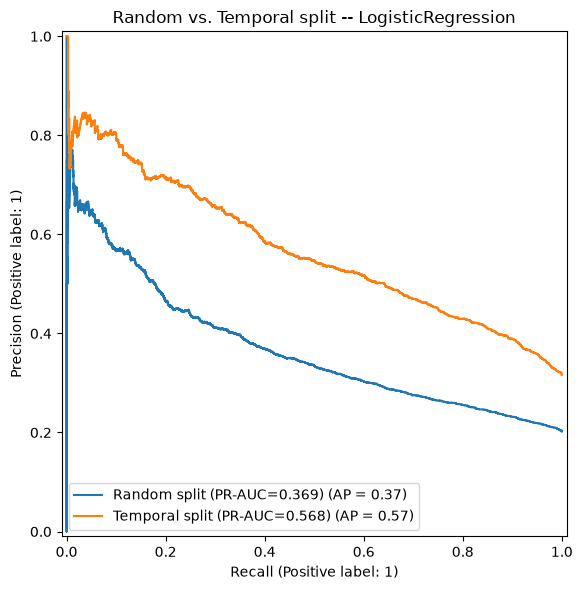

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
PrecisionRecallDisplay.from_predictions(
    random_y, random_proba, name=f"Random split (PR-AUC={random_pr_auc:.3f})", ax=ax
)
PrecisionRecallDisplay.from_predictions(
    temporal_y, temporal_proba, name=f"Temporal split (PR-AUC={temporal_pr_auc:.3f})", ax=ax
)
ax.set_title("Random vs. Temporal split -- LogisticRegression")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "leakage_pr_curves.png", dpi=150)
plt.show()

In [7]:
import numpy as np


def sponsor_coefs(pipe, label):
    coefs = pipe.named_steps["clf"].coef_[0]
    names = pipe.named_steps["pre"].get_feature_names_out()
    df = pd.DataFrame({"feature": names, "coef": coefs, "pipeline": label})
    return df[df["feature"].str.contains("sponsor_prior")]


coef_compare = pd.concat(
    [sponsor_coefs(temporal_pipe, "temporal"), sponsor_coefs(random_pipe, "random")]
).sort_values(["feature", "pipeline"])
coef_compare

,feature,coef,pipeline
30,num__sponsor_prior_termination_rate,2.034287,random
30,num__sponsor_prior_termination_rate,2.238422,temporal
29,num__sponsor_prior_trial_count,0.000315,random
29,num__sponsor_prior_trial_count,0.000299,temporal


## A cleaner, controlled test of the leakage mechanism

The comparison above is confounded: the two test sets differ in size, positive rate, *and* how much accumulated sponsor/condition history their trials have (the random split's test set spans the entire 1990-2026 window, including early trials with thin point-in-time history; the temporal split's test set is entirely 2022+, where 30+ years of history has already accumulated). The coefficient check above also complicates the naive story -- `sponsor_prior_termination_rate`'s coefficient is *larger* under the temporal pipeline, not the random one.

To isolate the actual leakage mechanism (a model learning feature-label relationships using data that, chronologically, postdates what a production model could have seen), fix a **single, identical test set** and vary only whether the training pool is allowed to include trials that started *after* that test window:

- **Fixed test set:** trials with `2020-01-01 <= start_date < 2022-01-01` (the calib window -- chosen because it has later data, 2022+, available to potentially leak from).
- **Honest train:** only `start_date < 2020-01-01` -- everything strictly before the test window.
- **Leaky train:** a same-size random sample drawn from *everywhere except* the test window, i.e. allowed to include `start_date >= 2022-01-01` -- trials that postdate every trial in the fixed test set.

Same test set, same size training set, same model -- the only difference is whether training was allowed to see chronologically-future (relative to the test window) trials.

In [8]:
start = pd.to_datetime(feat["start_date"])
fixed_test = feat[(start >= "2020-01-01") & (start < "2022-01-01")].copy()
honest_pool = feat[start < "2020-01-01"].copy()
leaky_pool = feat[(start < "2020-01-01") | (start >= "2022-01-01")].copy()

honest_train = honest_pool
leaky_train = leaky_pool.sample(n=len(honest_train), random_state=42)

print(f"Fixed test set: {len(fixed_test)} rows, {fixed_test['label'].mean():.4f} positive")
print(f"Honest train:   {len(honest_train)} rows (all start_date < 2020-01-01)")
print(f"Leaky train:    {len(leaky_train)} rows (same size, drawn incl. start_date >= 2022-01-01)")
print(f"  -> leaky train includes {(pd.to_datetime(leaky_train['start_date']) >= '2022-01-01').sum()} "
      f"trials that postdate the entire fixed test window")


def one_hot_fit_on_train(train_df, test_df, top_n=20):
    top = train_df["condition_name"].value_counts().head(top_n).index.tolist()

    def bucket(s):
        return s.where(s.isin(top) | (s == "unknown"), other="other")

    train_dummies = pd.get_dummies(bucket(train_df["condition_name"]), prefix="condition")
    test_dummies = pd.get_dummies(bucket(test_df["condition_name"]), prefix="condition")
    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=False)
    return (
        pd.concat([train_df.reset_index(drop=True), train_dummies.reset_index(drop=True)], axis=1),
        pd.concat([test_df.reset_index(drop=True), test_dummies.reset_index(drop=True)], axis=1),
        train_dummies.columns.tolist(),
    )


def fit_eval_fixed(train_df, test_df):
    train_df, test_df, cond_cols = one_hot_fit_on_train(train_df, test_df)
    cols = CATEGORICAL + NUMERIC + cond_cols
    pipe = make_pipeline(cond_cols)
    pipe.fit(train_df[cols], train_df["label"])
    proba = pipe.predict_proba(test_df[cols])[:, 1]
    return average_precision_score(test_df["label"], proba), roc_auc_score(test_df["label"], proba)


honest_pr, honest_roc = fit_eval_fixed(honest_train, fixed_test)
leaky_pr, leaky_roc = fit_eval_fixed(leaky_train, fixed_test)

pd.DataFrame(
    [
        {"train": "honest (< 2020 only)", "pr_auc": honest_pr, "roc_auc": honest_roc},
        {"train": "leaky (incl. >= 2022)", "pr_auc": leaky_pr, "roc_auc": leaky_roc},
    ]
).set_index("train")

Fixed test set: 6310 rows, 0.3025 positive
Honest train:   66105 rows (all start_date < 2020-01-01)
Leaky train:    66105 rows (same size, drawn incl. start_date >= 2022-01-01)
  -> leaky train includes 5276 trials that postdate the entire fixed test window


/Users/shubhamagrawal/Documents/MS_fall_25/MS_fall_25_uni/ds_projects/trialoutcome/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/shubhamagrawal/Documents/MS_fall_25/MS_fall_25_uni/ds_projects/trialoutcome/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,pr_auc,roc_auc
train,,
honest (< 2020 only),0.456776,0.659930
leaky (incl. >= 2022),0.455794,0.659108


## Why the gap exists -- and why the naive story is wrong

The raw random-vs-temporal PR-AUC gap (0.37 vs 0.57) is **not** evidence of the textbook "random split leaks future sponsor outcomes" mechanism the spec anticipated -- three checks rule that out:

1. **ROC-AUC** (far less sensitive to test-set prevalence) still favors the temporal split (0.73 vs 0.68), so this isn't purely a base-rate artifact of the temporal test set having a higher positive rate (31.7% vs 20.2%).
2. **`sponsor_prior_termination_rate`'s coefficient is *larger* under the temporal pipeline** (2.24 vs 2.03), the opposite of what "random split leaks sponsor history" would predict.
3. **The controlled ablation** (fixed test window, only varying whether training data was allowed to include trials chronologically *after* that window) shows **no meaningful difference**: PR-AUC 0.457 (honest) vs 0.456 (leaky), ROC-AUC 0.660 vs 0.659. Deliberately letting the model train on 5,276 trials that postdate the entire test window changed nothing.

**What's actually happening:** the point-in-time self-join in `domains/pharma/dataset_builder.py` (`sponsor_history`/`condition_rarity` CTEs, `hist.start_date < t.start_date`) computes every row's features correctly *regardless of which split that row lands in*. A trial's `sponsor_prior_termination_rate` never encodes information from after its own `start_date`, whether it ends up in train, calib, or test. That closes off leakage at the feature level -- which is exactly what the design is supposed to do, and the controlled ablation is direct evidence it's working for this feature set and model class.

The naive random-vs-temporal raw-metric gap instead reflects two confounds baked into *how row membership differs* between the two splits, not leakage:
- **Base-rate confound:** the random split's test set mirrors the whole-dataset positive rate (20.2%); the temporal split's test set is entirely 2022+, where termination rates have risen to ~31.7% (see the label-drift finding in `decisions.md`). PR-AUC is mechanically higher against a higher-prevalence test set for an equally-good model.
- **History-richness confound:** the random split's test set is drawn from the *entire* 1990-2026 window, including early trials where point-in-time sponsor/condition history is inherently thin (few prior trials exist that early in the dataset's coverage). The temporal split's test set is entirely 2022+, where 30+ years of history has already accumulated -- making those predictions systematically easier regardless of split methodology.

**Why the temporal split is still mandatory, not just a nice-to-have:** this result is a property of *this specific, carefully-built feature set* (every feature here is already point-in-time safe by construction) and *this model class* (a linear model, which can't easily exploit subtle cross-period interaction effects). It is not a general license to use random splits. Two things would break it immediately: (1) a future feature computed carelessly -- e.g. pulling `dim_sponsor.success_rate` directly (a static lifetime aggregate, explicitly flagged as leakage-prone in `config.yaml`) instead of the point-in-time self-join -- would leak hard under a random split and this ablation methodology is exactly how you'd catch it; (2) M2 introduces higher-capacity models (RF/XGBoost/LightGBM) that can pick up subtler distributional shift effects a regularized LogReg cannot -- worth re-running this same controlled ablation once those models exist, rather than assuming a linear-model negative result generalizes. **(M9 note: this is exactly what happened -- XGBoost's controlled ablation in `train_pipeline.py`'s `run_controlled_ablation` also found no row-placement leakage, a true negative; the actual leak XGBoost had was a feature-semantics leak in `enrollment_count`, a different failure class this notebook was never built to test. See `decisions.md` M9-1.)**